In [308]:
import QUANTAXIS as QA
from QUANTAXIS.QAData.financial_mean import financial_dict
import pandas as pd


import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import sweetviz as sv

import time
import datetime

plt.rcParams['font.sans-serif']=['SimHei'] 
plt.rcParams['font.serif'] = ['KaiTi']
plt.rcParams['axes.unicode_minus'] = False 

from sklearn.neighbors.kde import KernelDensity  

# class Macro_Descer:
#     def __init__(self, )

def auto_describe(df):
    report = sv.analyze(finances_filted,pairwise_analysis='auto')
    report.show_notebook()
    
def codes_by_market(sse='sh',only_main=True):
    '''按照市场获取股票代码，分为3类sh，sz，all，默认只获取主板'''
    condition = []
    if sse =='all':
        condition.append('6')
        condition.append('0')
        if not only_main:
            condition.append('3')
            
    if sse == 'sh':
        condition.append('6')
    if sse == 'sz':
        condition.append('0')
        if not only_main:
            condition.append('3')
            
    assert len(condition), '参数错误，检查sse内容'
    return QA.QA_fetch_stock_list()[stock_list.code.map(lambda x:x[0] in condition)].code.unique().tolist()

def get_Q1_list(start, end):
    return [str(y)+'-03-31' for y in range(int(start), int(end)+1)]

def get_Q2_list(start, end):
    return [str(y)+'-06-30' for y in range(int(start), int(end)+1)]

def get_Q3_list(start, end):
    return [str(y)+'-09-30' for y in range(int(start), int(end)+1)]

def get_Q4_list(start, end):
    return [str(y)+'-12-31' for y in range(int(start), int(end)+1)]

def excute_for_multidate(data, func, **pramas):
    return data.groupby(level=0, group_keys=False).apply(func,**pramas)

def drop_by_quantile_multi(obj, floor=.00,upper=1., column=None):
    return excute_for_multidate(obj, drop_by_quantile, floor=floor,upper=upper, column=column).sort_index()

def drop_by_quantile(obj, floor=.00,upper=1., column=None):
    if isinstance(obj, pd.Series):
        qt = obj.quantile([floor,upper])
        return obj[(obj>=qt[floor]) & (obj<=qt[upper])]
    
    if isinstance(obj, pd.DataFrame):
        assert column, 'COLUMN CANT be NONE when obj is dataframe'
        qt = obj[column].quantile([floor,upper])
        return obj[(obj[column]>=qt[floor]) & (obj[column]<=qt[upper])]
        
    raise TypeError('obj must be series or dataframe')


In [271]:
# QA.QA_fetch_stock_block_adv().get_code('600419').data
# code_all = QA.QA_fetch_stock_list().code.unique().tolist()
code_all = codes_by_market('all')

In [125]:
# codes = QA.QA_fetch_stock_block_adv().get_block(['婴童概念','乳业']).code
QA.QA_fetch_stock_block_adv().data

type   source
blockname code                    
通达信88     000002       gn      tdx
          000028       gn      tdx
          000060       gn      tdx
          000069       gn      tdx
          000333       gn      tdx
...                   ...      ...
中证500     300496  csindex  tushare
          300595  csindex  tushare
          300618  csindex  tushare
          300630  csindex  tushare
          300699  csindex  tushare

[49008 rows x 2 columns]

In [365]:
%%time
# QA.QA_fetch_financial_report_adv('000001',get_Q4_list(2012,2019)).data
# QA.QA_fetch_financial_report_adv('000001','2017','2017',ltype='CN').data
finances = QA.QA_fetch_financial_report_adv(['000001','000002','000004'],['2017-03-31','2017-06-30','2017-09-30']).data


# finances.describe(include = 'all')
# finances['totalAssets'] = finances['totalAssets'].apply(lambda x: round(x/100000000,2))
# finances['ROE'] = finances['ROE'].apply(lambda x: round(x,1))
# finances.describe()
# finances.quantile([.01,.05,.1,.9,.95,.99])
# finances

def get_rank(data, codes=None,quantile=False, column=None):
    if len(data.index.names) >= 2:
        res = excute_for_multidate(data, lambda x: x.rank(ascending=False,pct=quantile))
    else:
        res =  data.rank(ascending=False,pct=quantile)
    
    if codes:
        return res.loc('')
    return res
        
# print(finances['ROE'].rank())
# finances.get_key(code_all, ['2017-03-31'], ['totalAssets','ROE'])

a = finances.sort_index(level='report_date').loc[(slice(pd.Timestamp('2017-03-31'),pd.Timestamp('2017-06-30')), ['000001','000002','000004']),['totalAssets','ROE']]
# b = a.groupby(level=0, group_keys=False).apply(lambda x: x.rank(ascending=False,pct=False))
# # a = finances.data.sort_index(level='report_date').loc[(slice(pd.Timestamp('2017-03-31'),pd.Timestamp('2017-06-30')), ['000001','000002','000004']),['totalAssets','ROE']]['ROE']
# # b = a.groupby(level=0, group_keys=False).apply(lambda x: x.rank(ascending=False,pct=False))
print(get_rank(a.reset_index("report_date",drop=True),'000001'))
print(a.reset_index("report_date",drop=True))



ValueError: No axis named 000001 for object type DataFrame

In [309]:
# finances_filted = finances[(finances['totalAssets'] > 2.9201) & (finances['totalAssets'] < 6243.5915)& (finances['ROE'] > -1.795)& (finances['ROE'] < 5.700)]
finances_filted = drop_by_quantile_multi(finances,.00,1.,'ROE')

# finances_filted.index.names
# finances['ROE'].loc[pd.IndexSlice['2017-03-31'],:].index
# finances.data.loc[pd.IndexSlice['2017-03-31',],:]
finances_filted
# excute_for_multidate(obj, drop_by_quantile, floor=floor,upper=upper, column=column)

code report_date     EPS  deductEPS  \
report_date code                                            
2017-03-31  000001  000001  2017-03-31  0.3100   0.310000   
            000002  000002  2017-03-31  0.0630   0.061300   
            000004  000004  2017-03-31 -0.0140  -0.014026   
2017-06-30  000001  000001  2017-06-30  0.6800   0.680000   
            000002  000002  2017-06-30  0.6600   0.650000   
            000004  000004  2017-06-30 -0.0449  -0.046400   
2017-09-30  000001  000001  2017-09-30  1.0600   1.060000   
            000002  000002  2017-09-30  1.0050   0.959812   
            000004  000004  2017-09-30 -0.0647  -0.066166   

                    undistributedProfitPerShare  netAssetsPerShare  \
report_date code                                                     
2017-03-31  000001                       4.0467            10.9400   
            000002                       5.6069            10.3243   
            000004                       0.2850             1.4247   
2017-06-30  000001                       4.2579            11.1500   
            000002                       5.4155            10.2037   
            000004                       0.2541             1.3938   
2017-09-30  000001                       4.6422            11.5400   
            000002                       5.7586            10.5419   
            000004                       0.2344             1.3741   

                    capitalReservePerShare    ROE  operatingCashFlowPerShare  \
report_date code                                                               
2017-03-31  000001                  3.2885  2.992                     -6.700   
            000002                  0.7570  0.610                     -0.863   
            000004                  0.0079 -0.985                     -0.119   
2017-06-30  000001                  3.2885  6.100                     -7.470   
            000002                  0.8341  6.483                      1.979   
            000004                  0.0079 -3.223                     -0.070   
2017-09-30  000001                  3.2885  8.782                     -9.200   
            000002                  0.8206  9.531                      1.513   
            000004                  0.0079 -4.710                      0.053   

                      moneyFunds  ...  unknown570     unknown571  unknown572  \
report_date code                  ...                                          
2017-03-31  000001  4.426070e+11  ...         0.0  188404.203125   8225100.0   
            000002  9.096915e+10  ...         0.0       0.000000         0.0   
            000004  1.044106e+08  ...         0.0       0.000000         0.0   
2017-06-30  000001  4.623000e+11  ...         0.0       0.000000  13857300.0   
            000002  1.075632e+11  ...         0.0       0.000000         0.0   
            000004  1.083004e+08  ...         0.0       0.000000         0.0   
2017-09-30  000001  4.467960e+11  ...         0.0  261018.812500  20226500.0   
            000002  9.435263e+10  ...         0.0       0.000000         0.0   
            000004  1.183076e+08  ...         0.0       0.000000         0.0   

                    unknown573  unknown574  unknown575  unknown576  \
report_date code                                                     
2017-03-31  000001   2431300.0         0.0   1357800.0         0.0   
            000002         0.0         0.0         0.0         0.0   
            000004         0.0         0.0         0.0         0.0   
2017-06-30  000001   4406200.0         0.0   2822700.0         0.0   
            000002         0.0         0.0         0.0         0.0   
            000004         0.0         0.0         0.0         0.0   
2017-09-30  000001   5375400.0         0.0   4425000.0         0.0   
            000002         0.0         0.0         0.0         0.0   
            000004         0.0         0.0         0.0         0.0   

                      unknown577     unknown57

                                             |          | [  0%]   00:00 -> (? left)


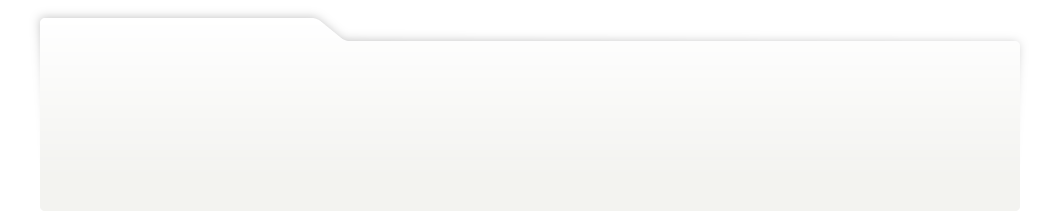
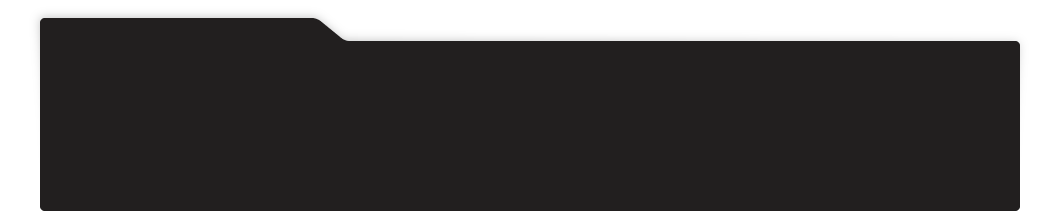
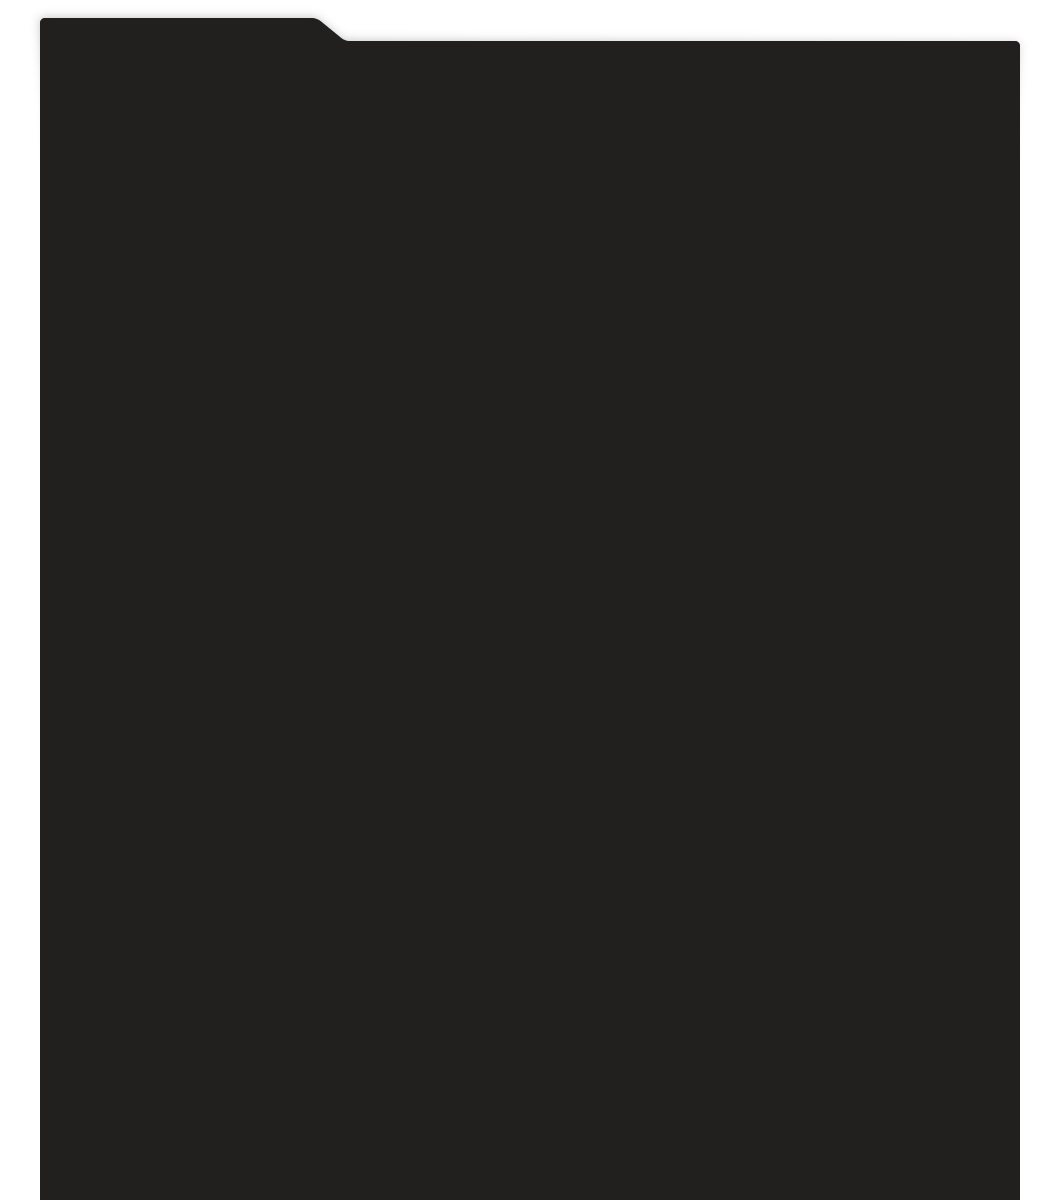
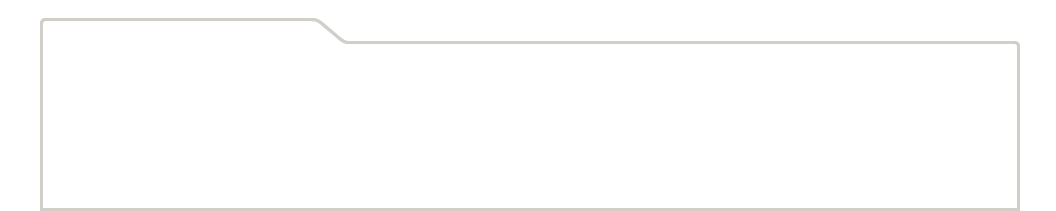
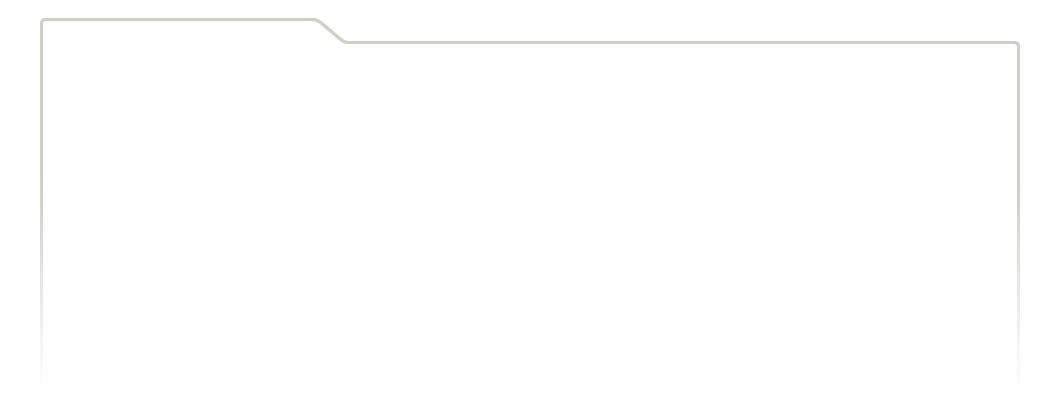
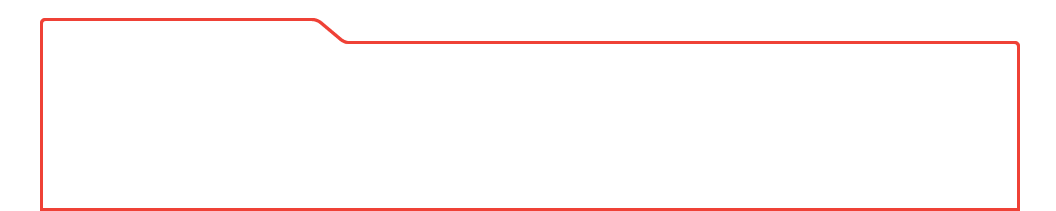
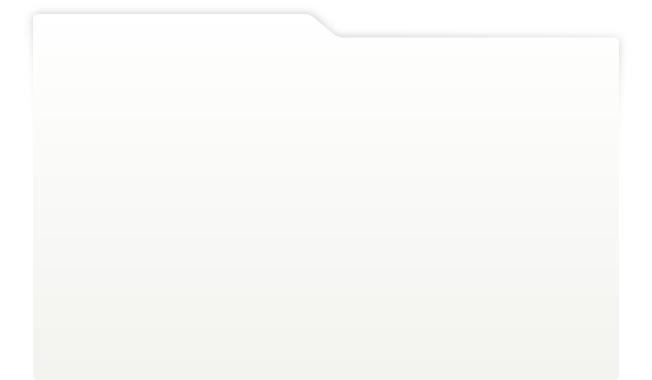
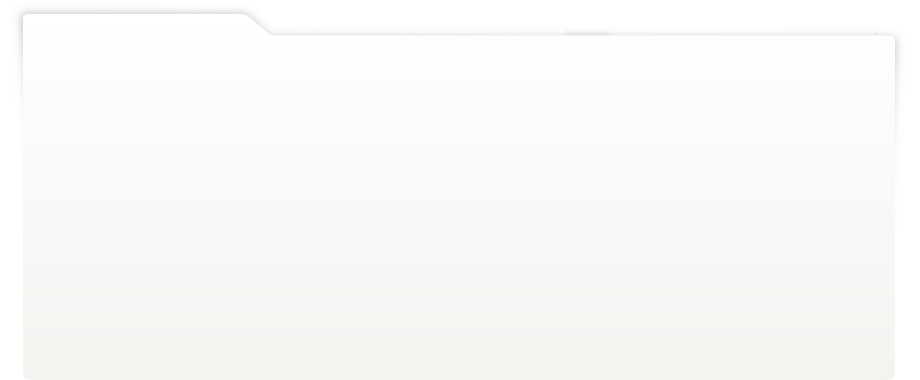
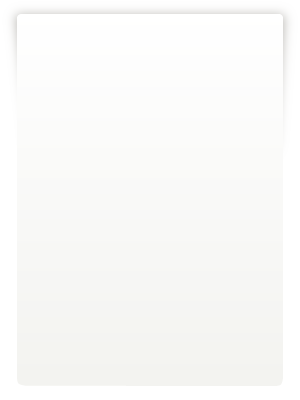
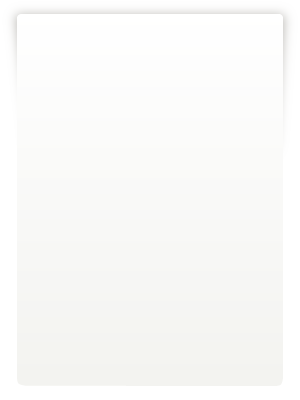
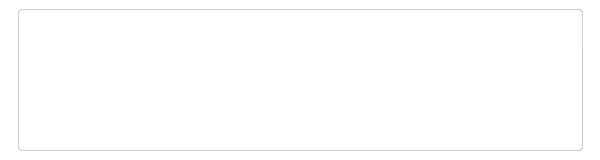
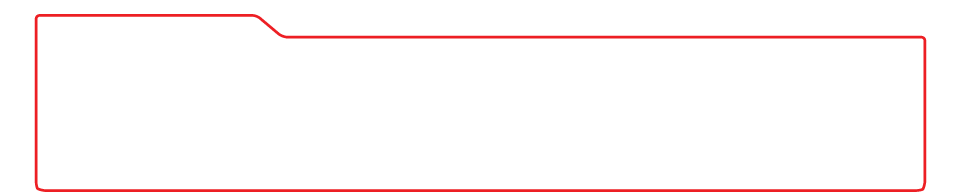
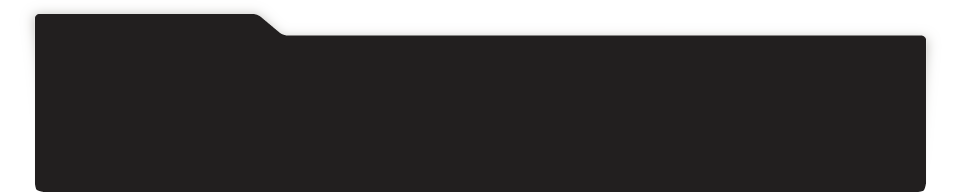
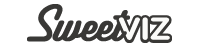
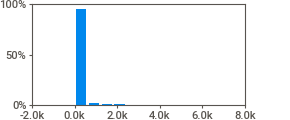
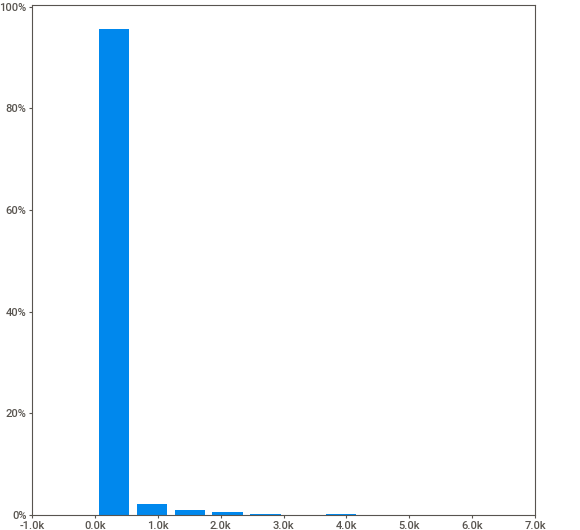
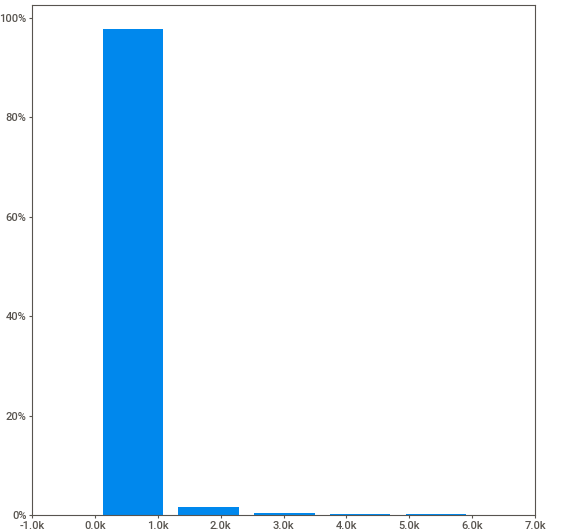
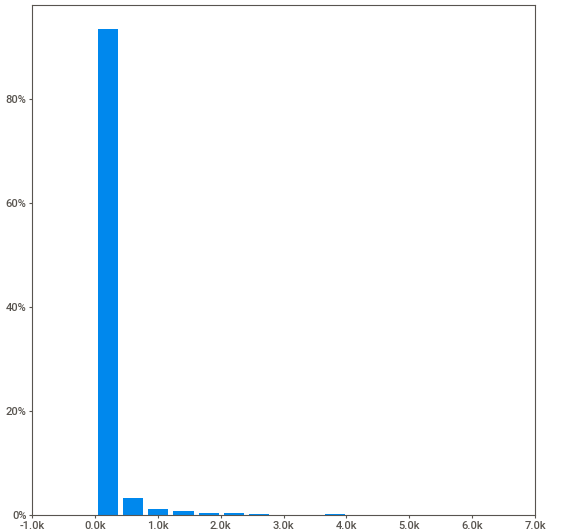
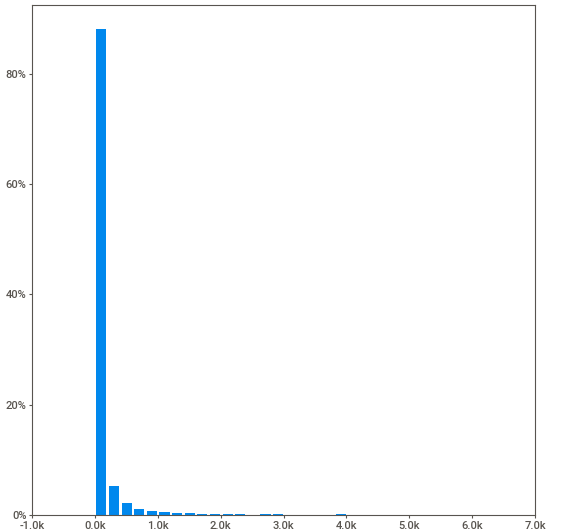
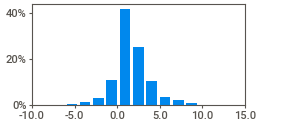
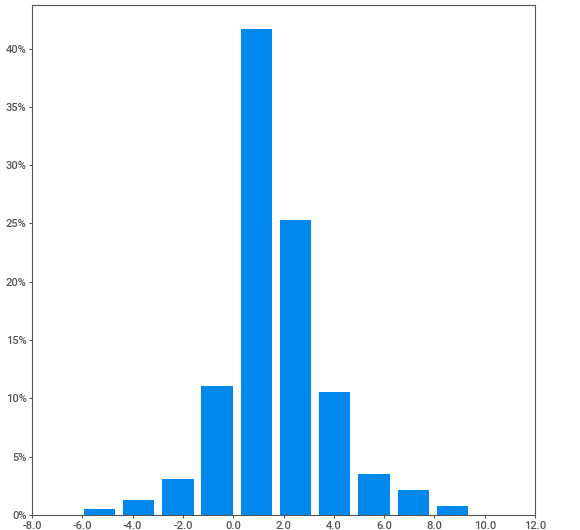
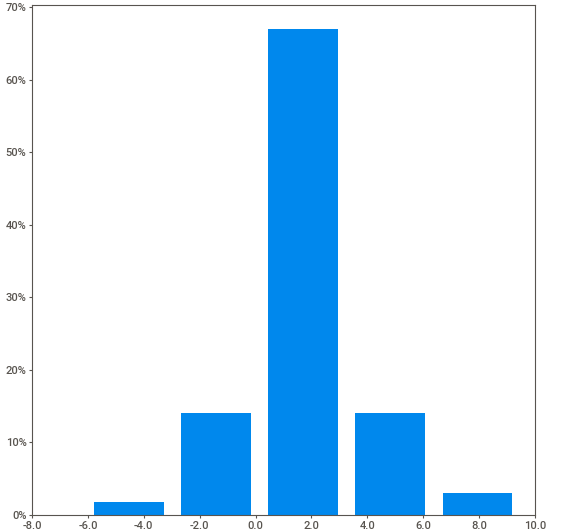
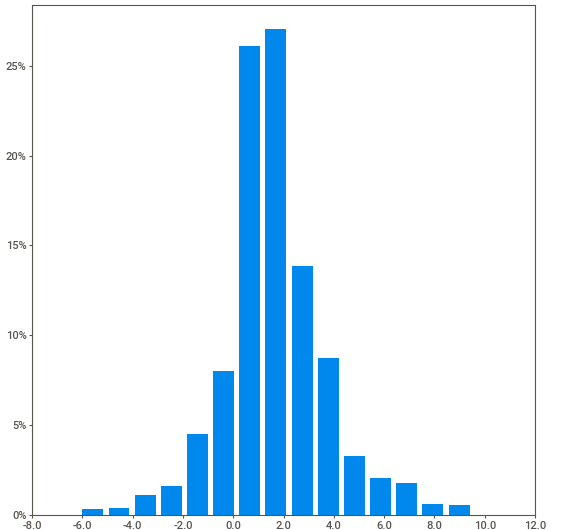
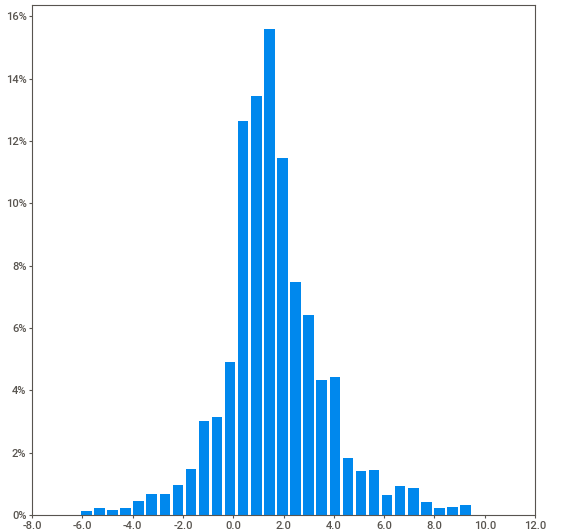
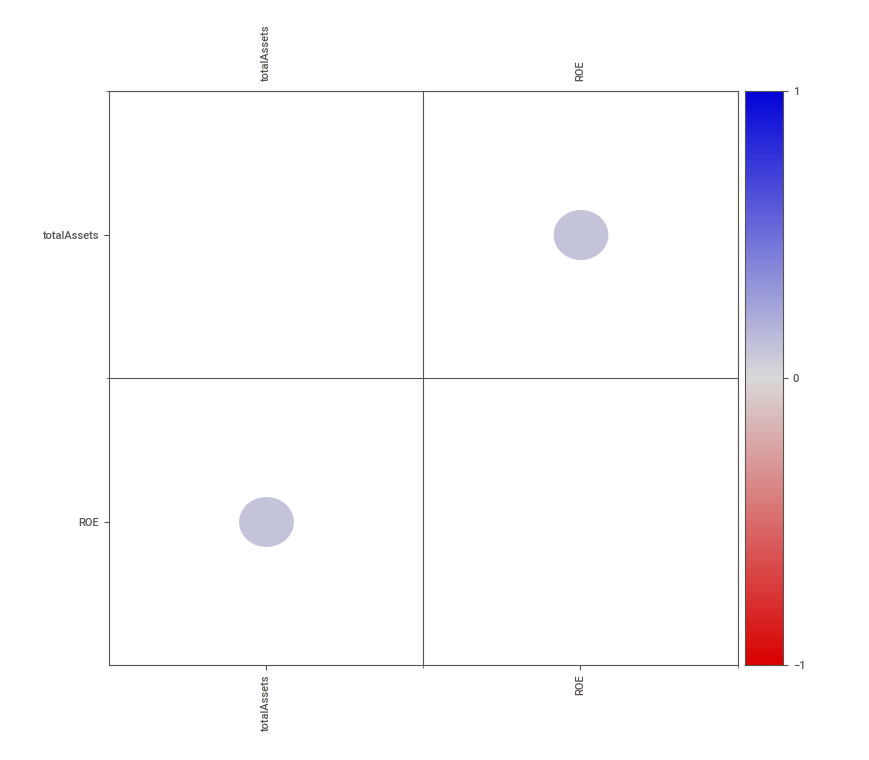
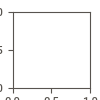

In [91]:
# get_Q4_list(2012,2019)
# import sweetviz as sv
# report = sv.analyze(finances_filted,pairwise_analysis='auto')
report.show_notebook()

<AxesSubplot:ylabel='Density'>

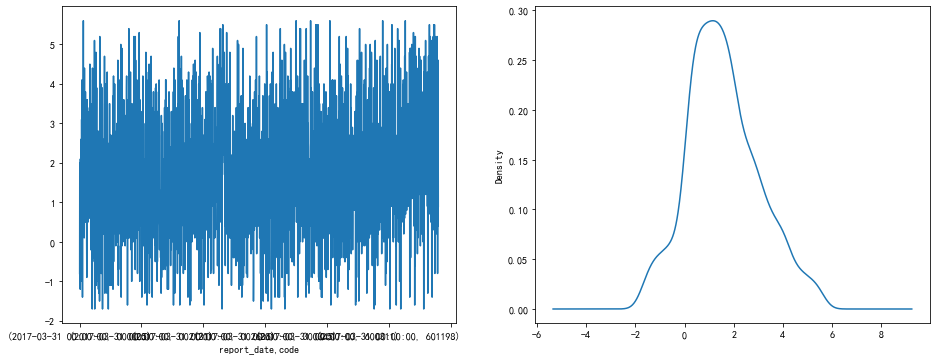

In [38]:
fig = plt.figure(figsize=(1120/72,420/72))
finances_filted['ROE'].plot(ax=fig.add_subplot(1,2,1))
# plt.scatter(finances_filted['ROE'].index.get_level_values('code'),finances_filted['ROE'].values)
finances_filted['ROE'].plot(kind="kde",ax=fig.add_subplot(1,2,2))
# finances_filted['ROE'].describe()
# finances_filted['totalAssets'].mean()
# plt.show()


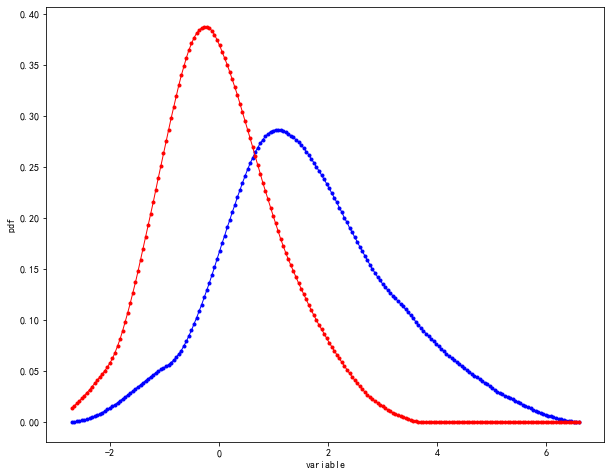

In [81]:
X_plot = np.linspace((finances_filted['ROE']).min()-1, (finances_filted['ROE']).max()+1, 200)[:, np.newaxis]
kde = KernelDensity(kernel='epanechnikov', bandwidth=1).fit((finances_filted['ROE']).values.reshape(-1, 1))  # 高斯核密度估计
log_dens = kde.score_samples(X_plot)  # 返回的是点x对应概率密度的log值，需要使用exp求指数还原
##params=kde.get_params()
plt.figure(figsize = (10, 8))  # 设置画布大小
plt.plot(X_plot, np.exp(log_dens), marker='.', linewidth=1, c="b", label='kernel density')
plt.xlabel('variable')
plt.ylabel('pdf')

kde = KernelDensity(kernel='epanechnikov', bandwidth=1).fit(((finances_filted['ROE']-finances_filted['ROE'].mean())/finances_filted['ROE'].std()).values.reshape(-1, 1))  # 高斯核密度估计
log_dens = kde.score_samples(X_plot)  # 返回的是点x对应概率密度的log值，需要使用exp求指数还原
plt.plot(X_plot, np.exp(log_dens), marker='.', linewidth=1, c="r", label='kernel density')


plt.show()

# finances_filted.columns.size

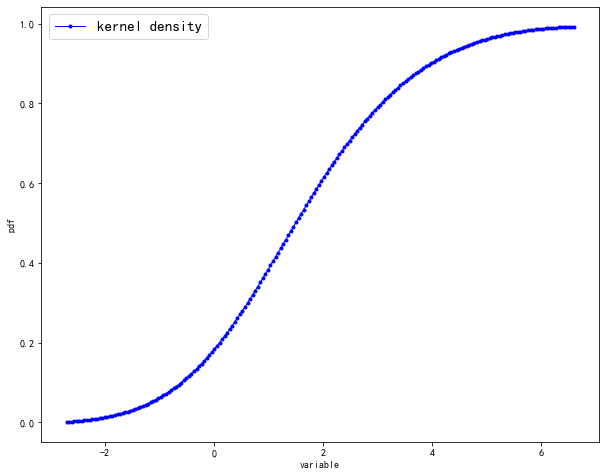

In [49]:
plt.figure(figsize = (10, 8))  # 设置画布大小
plt.plot(X_plot, np.cumsum(np.exp(log_dens)*np.abs(X_plot[0]-X_plot[1])), marker='.', linewidth=1, c="b", label='kernel density')
plt.xlabel('variable')
plt.ylabel('pdf')
plt.legend(fontsize = 15)  # 显示图例,设置图例字体大小
plt.show()


In [59]:
np.exp( kde.score_samples(np.array([1.3,1.3]).reshape(-1,1)))

array([0.28077963, 0.28077963])

In [62]:
np.exp(kde.score(np.array([1.3,1.3]).reshape(-1,1)))

0.07883720328173173

In [356]:
c = pd.DataFrame([{"a":11,"b":123,"c":1255},{"a":11,"b":2123,"c":222},{"a":333,"b":3333,"c":3}])
print(c.set_index('a'))
print(c.rank())
print(c.set_index('a').rank())


        b     c
a              
11    123  1255
11   2123   222
333  3333     3
     a    b    c
0  1.5  1.0  3.0
1  1.5  2.0  2.0
2  3.0  3.0  1.0
       b    c
a            
11   1.0  3.0
11   2.0  2.0
333  3.0  1.0
